/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2702836785.py:38: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2702836785.py:38: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2702836785.py:38: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2702836785.py:53: RuntimeWarning: divide by zero encountered in matmul
  Tx_eval.T @ A_factors[:, r],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2702836785.py:53: RuntimeWarning: overflow encountered in matmul
  Tx_eval.T @ A_factors[:, r],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2702836785.py:53: RuntimeWarning: invalid value encountered in matmul
  Tx_eval.

Rank 1: RMSE (function) = 2.66e-02, MaxE (function) = 6.09e-02, L2 Norm (coeff) = 3.09e-02
Rank 2: RMSE (function) = 4.39e-03, MaxE (function) = 2.72e-02, L2 Norm (coeff) = 7.40e-03
Rank 3: RMSE (function) = 8.00e-04, MaxE (function) = 3.95e-03, L2 Norm (coeff) = 1.28e-03
Rank 4: RMSE (function) = 2.75e-04, MaxE (function) = 1.46e-03, L2 Norm (coeff) = 2.14e-04
Rank 5: RMSE (function) = 2.50e-04, MaxE (function) = 1.31e-03, L2 Norm (coeff) = 3.76e-05
Rank 6: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 5.78e-06
Rank 7: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 6.31e-07
Rank 8: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 4.84e-08
Rank 9: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 2.66e-09
Rank 10: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 1.03e-10
Rank 11: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 2.75e-

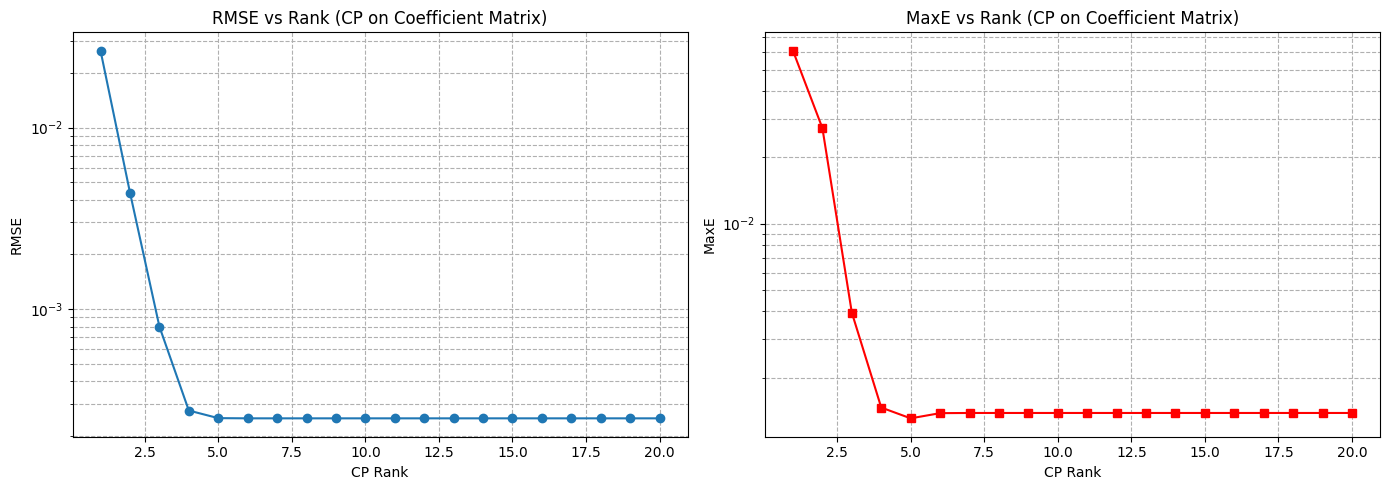

In [1]:
# CP Decomposition of Chebyshev Interpolation Coefficients with Error Analysis

import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import parafac
import tensorly as tl

# Function to be interpolated
def fcn(x, c):
    return 1 / (1 + c**2 * np.sum(x**2, axis=1))

# Chebyshev polynomial generator
def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Step 1: Generate coefficient matrix using QR
def generate_coeff_matrix(N, c):
    kx = np.arange(N+1)
    ky = np.arange(N+1)
    x_nodes = np.cos((2*kx + 1) * np.pi / (2*(N+1)))
    y_nodes = np.cos((2*ky + 1) * np.pi / (2*(N+1)))
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing="ij")

    coords = np.stack([X.ravel(), Y.ravel()], axis=1)
    F = fcn(coords, c).reshape((N+1, N+1))

    Tx = chebyshev_polys(x_nodes, N)
    Ty = chebyshev_polys(y_nodes, N)
    F_flat = F.T.ravel()
    A = np.kron(Ty.T, Tx.T)
    Q, R = np.linalg.qr(A)
    c_flat = np.linalg.solve(R, Q.T @ F_flat)
    return c_flat.reshape((N+1, N+1)), x_nodes, y_nodes

# Step 2: Function evaluator via CP-decomposed coefficient matrix
def evaluate_chebyshev_interp(CP_weights, A_factors, B_factors, N, resolution=100, c=5):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    Tx_eval = chebyshev_polys(xx, N)
    Ty_eval = chebyshev_polys(yy, N)

    # Build function approximation from CP
    Z_cp = np.zeros((resolution, resolution))
    for r in range(len(CP_weights)):
        Z_cp += CP_weights[r] * np.outer(
            Tx_eval.T @ A_factors[:, r],
            Ty_eval.T @ B_factors[:, r]
        )
    return Z_cp

# Step 3: Ground truth evaluator
def compute_exact_function_grid(fcn, c, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    coords = np.stack([XX.ravel(), YY.ravel()], axis=1)
    F = fcn(coords, c).reshape((resolution, resolution))
    return F

# Configs
N = 32
c = 5
resolution = 100

# TensorLy backend
tl.set_backend('numpy')

# Get coefficient matrix
C, x_nodes, y_nodes = generate_coeff_matrix(N, c)

# CP decomposition of coefficient matrix
ranks = range(1, 21)
rmse_errors = []
maxe_errors = []

F_true = compute_exact_function_grid(fcn, c, resolution=resolution)

for rank in ranks:
    cp_tensor = parafac(C, rank=rank, init='svd')
    weights, factors = cp_tensor.weights, cp_tensor.factors
    A_factors, B_factors = factors  # shapes: (N+1, rank)

    # Evaluate interpolant using CP-decomposed coefficient matrix
    F_cp = evaluate_chebyshev_interp(weights, A_factors, B_factors, N, resolution, c)

    # Compute error with true function values (function reconstruction error)
    diff_func = F_true - F_cp
    rmse_func = np.sqrt(np.mean(diff_func**2))
    maxe_func = np.max(np.abs(diff_func))

    # Reconstruct the coefficient matrix from CP
    C_reconstructed = tl.cp_to_tensor(cp_tensor)

    # Compute L2 norm between original and reconstructed coefficient matrix
    diff_coeff = C - C_reconstructed
    l2_norm_coeff = np.linalg.norm(diff_coeff)

    # Store function approximation error
    rmse_errors.append(rmse_func)
    maxe_errors.append(maxe_func)

    print(f"Rank {rank}: RMSE (function) = {rmse_func:.2e}, MaxE (function) = {maxe_func:.2e}, L2 Norm (coeff) = {l2_norm_coeff:.2e}")


# Step 4: Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# RMSE Plot
axs[0].plot(ranks, rmse_errors, marker='o')
axs[0].set_title("RMSE vs Rank (CP on Coefficient Matrix)")
axs[0].set_xlabel("CP Rank")
axs[0].set_ylabel("RMSE")
axs[0].set_yscale("log")
axs[0].grid(True, which='both', linestyle='--')

# MaxE Plot
axs[1].plot(ranks, maxe_errors, marker='s', color='red')
axs[1].set_title("MaxE vs Rank (CP on Coefficient Matrix)")
axs[1].set_xlabel("CP Rank")
axs[1].set_ylabel("MaxE")
axs[1].set_yscale("log")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


In [2]:
# Evaluate the interpolant directly from the original coefficients
def evaluate_chebyshev_direct(C, x_eval, y_eval, N):
    Tx_eval = chebyshev_polys(x_eval, N)
    Ty_eval = chebyshev_polys(y_eval, N)
    return Tx_eval.T @ C @ Ty_eval

# Compute true function on the grid (already done earlier)
F_true = compute_exact_function_grid(fcn, c, resolution=resolution)

# Evaluate interpolation directly
xx = np.linspace(-1, 1, resolution)
yy = np.linspace(-1, 1, resolution)
F_interp = evaluate_chebyshev_direct(C, xx, yy, N)

# Compute baseline errors
diff_baseline = F_true - F_interp
rmse_baseline = np.sqrt(np.mean(diff_baseline**2))
maxe_baseline = np.max(np.abs(diff_baseline))

print(f"[Baseline] RMSE: {rmse_baseline:.2e}, MaxE: {maxe_baseline:.2e}")


[Baseline] RMSE: 2.49e-04, MaxE: 1.38e-03


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/4207917614.py:5: RuntimeWarning: divide by zero encountered in matmul
  return Tx_eval.T @ C @ Ty_eval
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/4207917614.py:5: RuntimeWarning: overflow encountered in matmul
  return Tx_eval.T @ C @ Ty_eval
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/4207917614.py:5: RuntimeWarning: invalid value encountered in matmul
  return Tx_eval.T @ C @ Ty_eval


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2669183882.py:53: RuntimeWarning: divide by zero encountered in matmul
  Tx_eval.T @ A_factors[:, r],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2669183882.py:53: RuntimeWarning: overflow encountered in matmul
  Tx_eval.T @ A_factors[:, r],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2669183882.py:53: RuntimeWarning: invalid value encountered in matmul
  Tx_eval.T @ A_factors[:, r],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2669183882.py:54: RuntimeWarning: divide by zero encountered in matmul
  Ty_eval.T @ B_factors[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2669183882.py:54: RuntimeWarning: overflow encountered in matmul
  Ty_eval.T @ B_factors[:, r]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2669183882.py:54: RuntimeWarning: invalid value encountered in matmul
  Ty_eval.T @ B_factors[:, r]


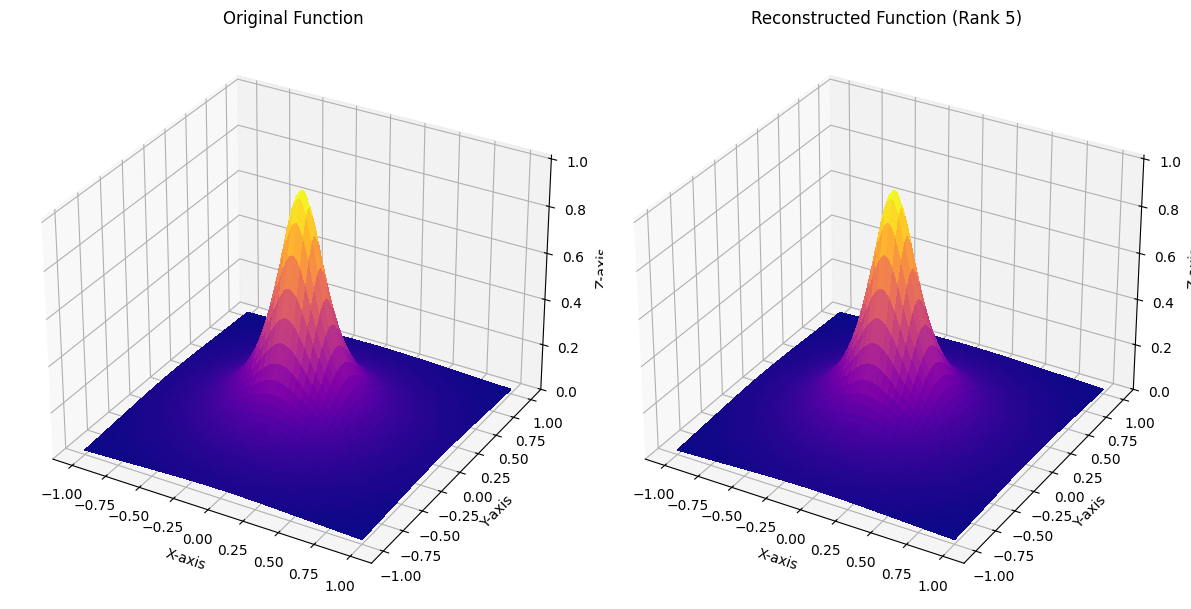

In [3]:
from matplotlib import cm

# Choose the rank you want to visualize
rank = 5
cp_tensor = parafac(C, rank=rank, init='svd')
weights, (A_factors, B_factors) = cp_tensor

# Evaluate CP-based interpolation
F_cp = evaluate_chebyshev_interp(weights, A_factors, B_factors, N, resolution, c)

# Prepare meshgrid for visualization
xx = np.linspace(-1, 1, resolution)
yy = np.linspace(-1, 1, resolution)
X_vis, Y_vis = np.meshgrid(xx, yy, indexing="ij")
F_true = compute_exact_function_grid(fcn, c, resolution)

fig = plt.figure(figsize=(12, 6))

# Original function
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_vis, Y_vis, F_true, cmap=cm.plasma, linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# Reconstructed function
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_vis, Y_vis, F_cp, cmap=cm.plasma, linewidth=0, antialiased=False)
ax2.set_title(f'Reconstructed Function (Rank {rank})')
ax2.set_xlabel('X-axis')
ax2.set_ylabel('Y-axis')
ax2.set_zlabel('Z-axis')

plt.tight_layout()
plt.show()


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2737732153.py:38: RuntimeWarning: divide by zero encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2737732153.py:38: RuntimeWarning: overflow encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2737732153.py:38: RuntimeWarning: invalid value encountered in matmul
  c_flat = np.linalg.solve(R, Q.T @ F_flat)
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2737732153.py:53: RuntimeWarning: divide by zero encountered in matmul
  Tx_eval.T @ A_factors[:, i],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2737732153.py:53: RuntimeWarning: overflow encountered in matmul
  Tx_eval.T @ A_factors[:, i],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_2481/2737732153.py:53: RuntimeWarning: invalid value encountered in matmul
  Tx_eval.

Rank 1: RMSE (function) = 2.66e-02, MaxE (function) = 6.09e-02, L2 Norm (coeff) = 3.09e-02
Rank 2: RMSE (function) = 4.39e-03, MaxE (function) = 2.72e-02, L2 Norm (coeff) = 7.40e-03
Rank 3: RMSE (function) = 8.00e-04, MaxE (function) = 3.95e-03, L2 Norm (coeff) = 1.28e-03
Rank 4: RMSE (function) = 2.75e-04, MaxE (function) = 1.46e-03, L2 Norm (coeff) = 2.14e-04
Rank 5: RMSE (function) = 2.50e-04, MaxE (function) = 1.31e-03, L2 Norm (coeff) = 3.76e-05
Rank 6: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 5.78e-06
Rank 7: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 6.31e-07
Rank 8: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 4.84e-08
Rank 9: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 2.66e-09
Rank 10: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 1.03e-10
Rank 11: RMSE (function) = 2.49e-04, MaxE (function) = 1.38e-03, L2 Norm (coeff) = 2.75e-

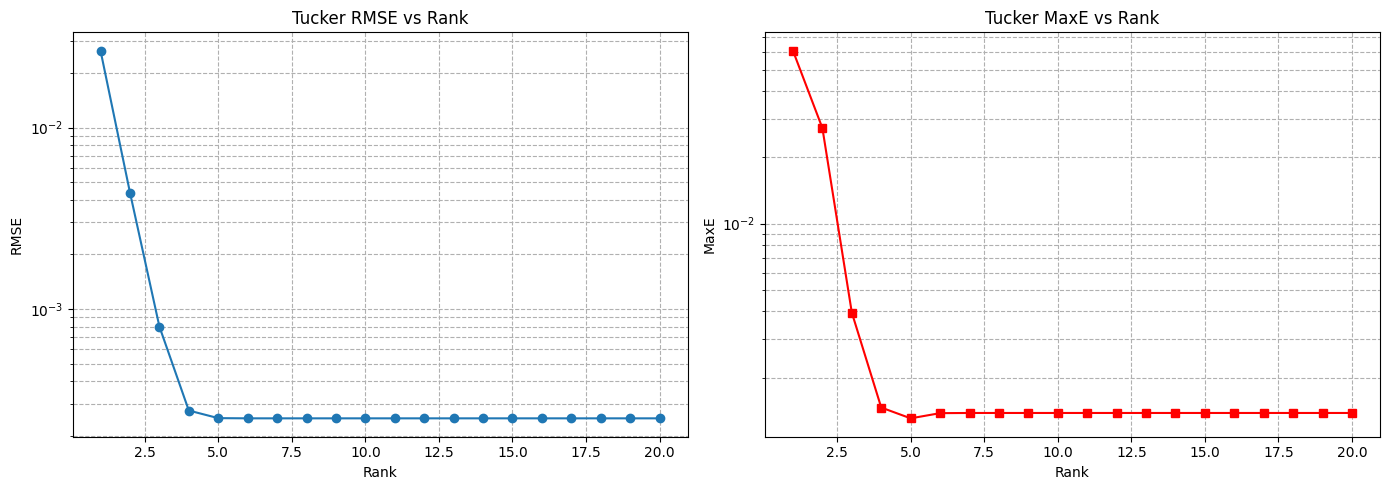

In [3]:
# Tucker Decomposition of Chebyshev Interpolation Coefficients with Error Analysis

import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import tucker
import tensorly as tl

# Function definition
def fcn(x, c):
    return 1 / (1 + c**2 * np.sum(x**2, axis=1))

# Chebyshev polynomial generator
def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Generate coefficient matrix
def generate_coeff_matrix(N, c):
    kx = np.arange(N+1)
    ky = np.arange(N+1)
    x_nodes = np.cos((2*kx + 1) * np.pi / (2*(N+1)))
    y_nodes = np.cos((2*ky + 1) * np.pi / (2*(N+1)))
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing="ij")

    coords = np.stack([X.ravel(), Y.ravel()], axis=1)
    F = fcn(coords, c).reshape((N+1, N+1))

    Tx = chebyshev_polys(x_nodes, N)
    Ty = chebyshev_polys(y_nodes, N)
    F_flat = F.T.ravel()
    A = np.kron(Ty.T, Tx.T)
    Q, R = np.linalg.qr(A)
    c_flat = np.linalg.solve(R, Q.T @ F_flat)
    return c_flat.reshape((N+1, N+1)), x_nodes, y_nodes

# Evaluate interpolated function using Tucker-decomposed coefficient matrix
def evaluate_tucker_interp(core, A_factors, B_factors, N, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    Tx_eval = chebyshev_polys(xx, N)
    Ty_eval = chebyshev_polys(yy, N)

    Z_tucker = np.zeros((resolution, resolution))
    for i in range(core.shape[0]):
        for j in range(core.shape[1]):
            Z_tucker += core[i, j] * np.outer(
                Tx_eval.T @ A_factors[:, i],
                Ty_eval.T @ B_factors[:, j]
            )
    return Z_tucker

# Exact function values for comparison
def compute_exact_function_grid(fcn, c, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    coords = np.stack([XX.ravel(), YY.ravel()], axis=1)
    return fcn(coords, c).reshape((resolution, resolution))

# Parameters
N = 32
c = 5
resolution = 100
tl.set_backend('numpy')

# Build coefficient matrix
C, x_nodes, y_nodes = generate_coeff_matrix(N, c)

# Ranks to try
ranks = range(1, 21)
rmse_errors = []
maxe_errors = []

F_true = compute_exact_function_grid(fcn, c, resolution)

# Tucker decomposition loop
for rank in ranks:
    # Perform Tucker decomposition
    core, [A, B] = tucker(C, rank=[rank, rank])

    # Evaluate interpolated function from Tucker-decomposed coeffs
    F_tucker = evaluate_tucker_interp(core, A, B, N, resolution)

    # Compute error with true function values
    diff_func = F_true - F_tucker
    rmse_func = np.sqrt(np.mean(diff_func**2))
    maxe_func = np.max(np.abs(diff_func))

    # Tucker reconstruction of coefficient matrix
    C_reconstructed = tl.tucker_to_tensor((core, [A, B]))
    l2_norm_coeff = np.linalg.norm(C - C_reconstructed)

    rmse_errors.append(rmse_func)
    maxe_errors.append(maxe_func)

    print(f"Rank {rank}: RMSE (function) = {rmse_func:.2e}, MaxE (function) = {maxe_func:.2e}, L2 Norm (coeff) = {l2_norm_coeff:.2e}")


# Plot results
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(ranks, rmse_errors, marker='o', label='RMSE')
axs[0].set_title("Tucker RMSE vs Rank")
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("RMSE")
axs[0].set_yscale("log")
axs[0].grid(True, which='both', linestyle='--')

axs[1].plot(ranks, maxe_errors, marker='s', color='red', label='MaxE')
axs[1].set_title("Tucker MaxE vs Rank")
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("MaxE")
axs[1].set_yscale("log")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2327470001.py:55: RuntimeWarning: divide by zero encountered in matmul
  Tx_eval.T @ A_factors[:, i],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2327470001.py:55: RuntimeWarning: overflow encountered in matmul
  Tx_eval.T @ A_factors[:, i],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2327470001.py:55: RuntimeWarning: invalid value encountered in matmul
  Tx_eval.T @ A_factors[:, i],
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2327470001.py:56: RuntimeWarning: divide by zero encountered in matmul
  Ty_eval.T @ B_factors[:, j]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2327470001.py:56: RuntimeWarning: overflow encountered in matmul
  Ty_eval.T @ B_factors[:, j]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2327470001.py:56: RuntimeWarning: invalid value encountered in matmul
  Ty_eval.T @ B_factors[:, j]


Rank 1, RMSE: 2.66e-02, MaxE: 6.10e-02
Rank 2, RMSE: 4.39e-03, MaxE: 2.73e-02
Rank 3, RMSE: 7.64e-04, MaxE: 3.83e-03
Rank 4, RMSE: 1.25e-04, MaxE: 6.54e-04
Rank 5, RMSE: 1.98e-05, MaxE: 9.48e-05
Rank 6, RMSE: 3.12e-06, MaxE: 1.46e-05
Rank 7, RMSE: 6.09e-07, MaxE: 3.70e-06
Rank 8, RMSE: 3.75e-07, MaxE: 2.59e-06
Rank 9, RMSE: 3.67e-07, MaxE: 2.35e-06
Rank 10, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 11, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 12, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 13, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 14, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 15, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 16, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 17, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 18, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 19, RMSE: 3.67e-07, MaxE: 2.34e-06
Rank 20, RMSE: 3.67e-07, MaxE: 2.34e-06


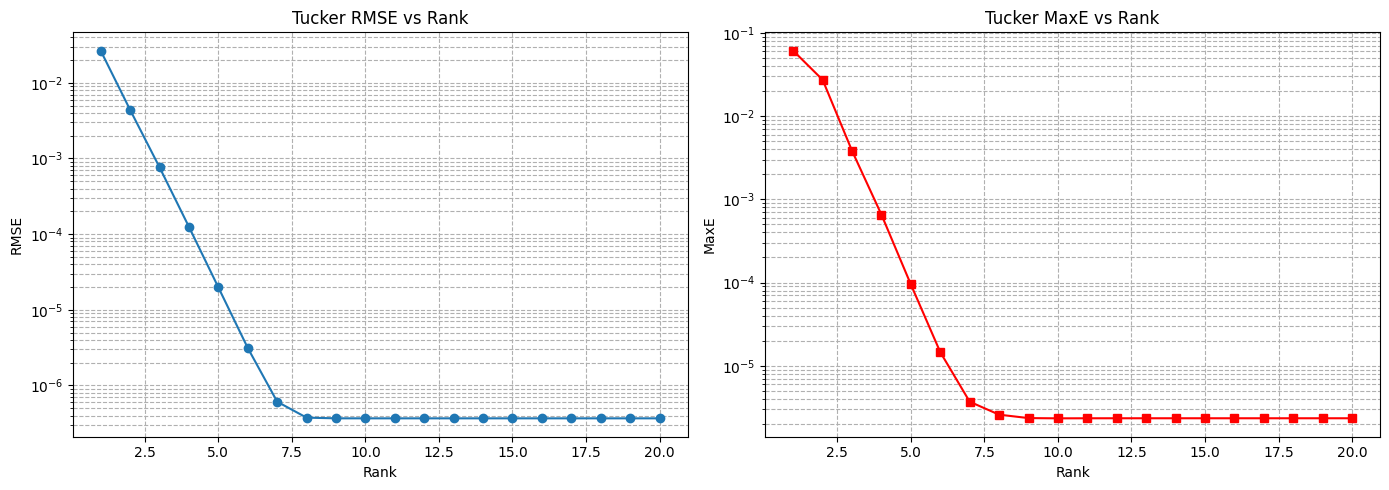

In [5]:
# Tucker Decomposition of Chebyshev Interpolation Coefficients with Error Analysis
# using Least Squares

import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import tucker
import tensorly as tl

# Function definition
def fcn(x, c):
    return 1 / (1 + c**2 * np.sum(x**2, axis=1))

# Chebyshev polynomial generator
def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Generate coefficient matrix
def generate_coeff_matrix(N, c):
    kx = np.arange(N+1)
    ky = np.arange(N+1)
    x_nodes = np.cos((2*kx + 1) * np.pi / (2*(N+1)))
    y_nodes = np.cos((2*ky + 1) * np.pi / (2*(N+1)))
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing="ij")

    coords = np.stack([X.ravel(), Y.ravel()], axis=1)
    F = fcn(coords, c).reshape((N+1, N+1))

    Tx = chebyshev_polys(x_nodes, N)
    Ty = chebyshev_polys(y_nodes, N)
    F_flat = F.T.ravel()
    A = np.kron(Ty.T, Tx.T)

    # Linear least squares solve: A c_flat ≈ F_flat
    c_flat, residuals, rank, s = np.linalg.lstsq(A, F_flat, rcond=None)
    return c_flat.reshape((N+1, N+1)), x_nodes, y_nodes

# Evaluate interpolated function using Tucker-decomposed coefficient matrix
def evaluate_tucker_interp(core, A_factors, B_factors, N, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    Tx_eval = chebyshev_polys(xx, N)
    Ty_eval = chebyshev_polys(yy, N)

    Z_tucker = np.zeros((resolution, resolution))
    for i in range(core.shape[0]):
        for j in range(core.shape[1]):
            Z_tucker += core[i, j] * np.outer(
                Tx_eval.T @ A_factors[:, i],
                Ty_eval.T @ B_factors[:, j]
            )
    return Z_tucker

# Exact function values for comparison
def compute_exact_function_grid(fcn, c, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    coords = np.stack([XX.ravel(), YY.ravel()], axis=1)
    return fcn(coords, c).reshape((resolution, resolution))

# Parameters
N = 64
c = 5
resolution = 100
tl.set_backend('numpy')

# Build coefficient matrix
C, x_nodes, y_nodes = generate_coeff_matrix(N, c)

# Ranks to try
ranks = range(1, 21)
rmse_errors = []
maxe_errors = []

F_true = compute_exact_function_grid(fcn, c, resolution)

# Tucker decomposition loop
for rank in ranks:
    # Perform Tucker decomposition
    core, [A, B] = tucker(C, rank=[rank, rank])

    # Evaluate interpolated function from Tucker-decomposed coeffs
    F_tucker = evaluate_tucker_interp(core, A, B, N, resolution)

    # Compute error
    diff = F_true - F_tucker
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)

    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Plot results
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(ranks, rmse_errors, marker='o', label='RMSE')
axs[0].set_title("Tucker RMSE vs Rank")
axs[0].set_xlabel("Rank")
axs[0].set_ylabel("RMSE")
axs[0].set_yscale("log")
axs[0].grid(True, which='both', linestyle='--')

axs[1].plot(ranks, maxe_errors, marker='s', color='red', label='MaxE')
axs[1].set_title("Tucker MaxE vs Rank")
axs[1].set_xlabel("Rank")
axs[1].set_ylabel("MaxE")
axs[1].set_yscale("log")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


TT Decomposition on Coeff Matrix -> RMSE (function): 5.16e-07, MaxE (function): 9.37e-06, L2 Norm (coeff): 1.05e-12


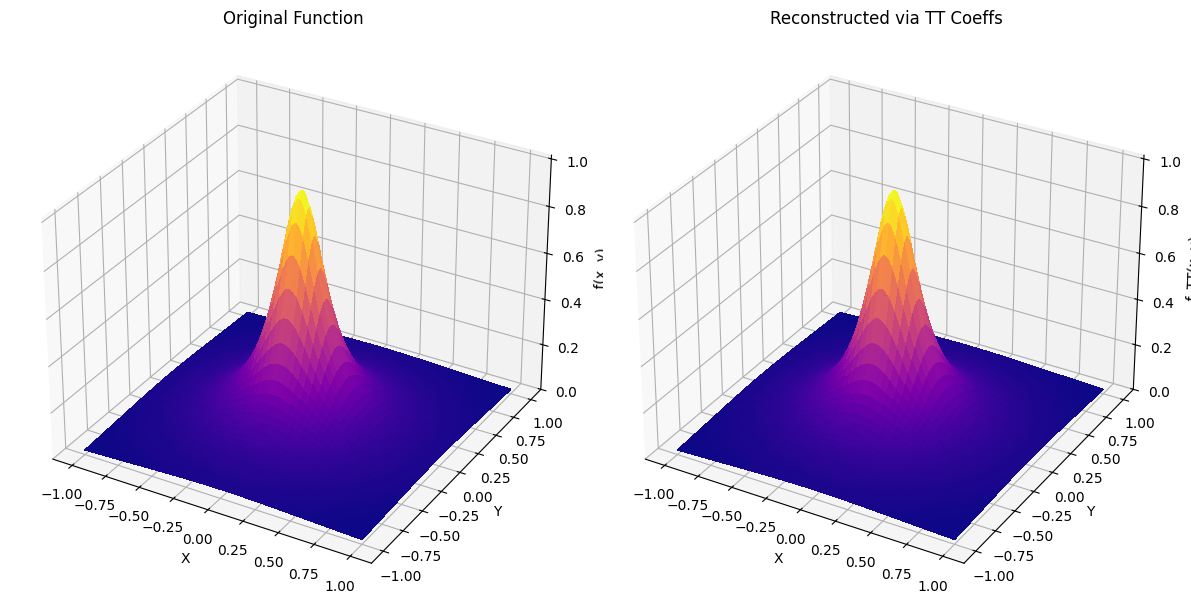

In [14]:
# Tensor Train Decomposition of Chebyshev Interpolation Coefficients with Error Analysis

import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import TensorTrain
from tensorly.tt_tensor import tt_to_tensor
import tensorly as tl

# Set backend
tl.set_backend('numpy')

# Define function
def fcn(x, c=5):
    return 1 / (1 + c**2 * np.sum(x**2, axis=1))

def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Generate coefficient matrix using least squares
def generate_coeff_matrix(N, c):
    kx = np.arange(N+1)
    ky = np.arange(N+1)
    x_nodes = np.cos((2*kx + 1) * np.pi / (2*(N+1)))
    y_nodes = np.cos((2*ky + 1) * np.pi / (2*(N+1)))
    X, Y = np.meshgrid(x_nodes, y_nodes, indexing="ij")
    coords = np.stack([X.ravel(), Y.ravel()], axis=1)
    F = fcn(coords, c).reshape((N+1, N+1))

    Tx = chebyshev_polys(x_nodes, N)
    Ty = chebyshev_polys(y_nodes, N)
    F_flat = F.T.ravel()
    A = np.kron(Ty.T, Tx.T)
    c_flat, *_ = np.linalg.lstsq(A, F_flat, rcond=None)
    return c_flat.reshape((N+1, N+1)), x_nodes, y_nodes

# Evaluate function using Chebyshev coefficients
def evaluate_interp(C, N, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    Tx_eval = chebyshev_polys(xx, N)
    Ty_eval = chebyshev_polys(yy, N)
    Z = np.zeros((resolution, resolution))
    for i in range(N+1):
        for j in range(N+1):
            Z += C[i, j] * np.outer(Tx_eval[i], Ty_eval[j])
    return Z

# Compute exact function
def compute_exact_function_grid(fcn, c, resolution=100):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    XX, YY = np.meshgrid(xx, yy, indexing="ij")
    coords = np.stack([XX.ravel(), YY.ravel()], axis=1)
    return fcn(coords, c).reshape((resolution, resolution))

# Main parameters
N = 63
c = 5
resolution = 100

# Get coefficient matrix
C, x_nodes, y_nodes = generate_coeff_matrix(N, c)

C_tensorized = C.reshape((2,2,2,2,2,2,2,2,2,2,2,2))

# Decompose using TT
tt_model = TensorTrain(rank='same', verbose=False)
tt_cores = tt_model.fit_transform(C_tensorized)

# Reconstruct
C_reconstructed_tensor = tt_to_tensor(tt_cores)
C_reconstructed = C_reconstructed_tensor.reshape((N+1, N+1))

# Evaluate interpolant with reconstructed coeffs
F_tt = evaluate_interp(C_reconstructed, N, resolution)

# Evaluate exact function
F_true = compute_exact_function_grid(fcn, c, resolution)

# Function value errors
diff_func = F_true - F_tt
rmse_func = np.sqrt(np.mean(diff_func**2))
maxe_func = np.max(np.abs(diff_func))

# Coefficient matrix L2 error
l2_norm_coeff = np.linalg.norm(C - C_reconstructed)

print(f"TT Decomposition on Coeff Matrix -> RMSE (function): {rmse_func:.2e}, MaxE (function): {maxe_func:.2e}, L2 Norm (coeff): {l2_norm_coeff:.2e}")


# Plot original vs TT-interpolated
fig = plt.figure(figsize=(12, 6))
xx = np.linspace(-1, 1, resolution)
yy = np.linspace(-1, 1, resolution)
X, Y = np.meshgrid(xx, yy, indexing="ij")

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, F_true, cmap='plasma', linewidth=0, antialiased=False)
ax1.set_title('Original Function')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('f(x, y)')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, F_tt, cmap='plasma', linewidth=0, antialiased=False)
ax2.set_title('Reconstructed via TT Coeffs')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('f_TT(x, y)')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import parafac
import tensorly as tl

# Set backend
tl.set_backend('numpy')

# Define 3D function
def f(xyz, c=5):
    return 1 / (1 + c**2 * np.sum(xyz**2, axis=1))

# Generate 3D Chebyshev polynomials
def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Step 1: Generate 3D coefficient tensor via least squares
def generate_coeff_tensor(N, c):
    k = np.arange(N+1)
    nodes = np.cos((2*k + 1) * np.pi / (2*(N+1)))
    X, Y, Z = np.meshgrid(nodes, nodes, nodes, indexing="ij")
    
    coords = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
    F = f(coords, c).reshape((N+1, N+1, N+1))

    Tx = chebyshev_polys(nodes, N)
    Ty = Tx.copy()
    Tz = Tx.copy()

    A = np.kron(Tz.T, np.kron(Ty.T, Tx.T))
    F_flat = F.ravel()
    c_flat, *_ = np.linalg.lstsq(A, F_flat, rcond=None)
    C = c_flat.reshape((N+1, N+1, N+1))
    return C, nodes

# Step 2: Evaluate function from CP-decomposed Chebyshev tensor
def evaluate_cp_interp(weights, factors, nodes, N, resolution=50):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    zz = np.linspace(-1, 1, resolution)
    Tx = chebyshev_polys(xx, N)
    Ty = chebyshev_polys(yy, N)
    Tz = chebyshev_polys(zz, N)
    F_cp = np.zeros((resolution, resolution, resolution))

    for r in range(len(weights)):
        a = Tx.T @ factors[0][:, r]
        b = Ty.T @ factors[1][:, r]
        c = Tz.T @ factors[2][:, r]
        F_cp += weights[r] * np.einsum("i,j,k->ijk", a, b, c)
    
    return F_cp

# Step 3: Compute ground truth on a dense grid
def compute_exact_function_grid(f, c, resolution=50):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    zz = np.linspace(-1, 1, resolution)
    X, Y, Z = np.meshgrid(xx, yy, zz, indexing="ij")
    coords = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
    F = f(coords, c).reshape((resolution, resolution, resolution))
    return F

# Parameters
N = 32
c = 5
resolution = 100
ranks = range(1, 11)

# Get 3D coefficient tensor
C, nodes = generate_coeff_tensor(N, c)
F_true = compute_exact_function_grid(f, c, resolution)

# CP decomposition and error computation
rmse_errors = []
maxe_errors = []

for rank in ranks:
    cp_tensor = parafac(C, rank=rank, init='svd')
    weights, factors = cp_tensor.weights, cp_tensor.factors

    # Evaluate interpolated function from CP coeffs
    F_cp = evaluate_cp_interp(weights, factors, nodes, N, resolution)

    # Function value error
    diff_func = F_true - F_cp
    rmse_func = np.sqrt(np.mean(diff_func**2))
    maxe_func = np.max(np.abs(diff_func))

    # Reconstruct coefficient tensor from CP
    C_reconstructed = tl.cp_to_tensor(cp_tensor)

    # L2 norm error in coefficient space
    l2_norm_coeff = np.linalg.norm(C - C_reconstructed)

    rmse_errors.append(rmse_func)
    maxe_errors.append(maxe_func)

    print(f"Rank {rank}: RMSE (function) = {rmse_func:.2e}, MaxE (function) = {maxe_func:.2e}, L2 Norm (coeff) = {l2_norm_coeff:.2e}")

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(ranks, rmse_errors, marker='o')
axs[0].set_yscale("log")
axs[0].set_title("3D CP: RMSE vs Rank")
axs[0].set_xlabel("CP Rank")
axs[0].set_ylabel("RMSE")
axs[0].grid(True, which='both', linestyle='--')

axs[1].plot(ranks, maxe_errors, marker='s', color='red')
axs[1].set_yscale("log")
axs[1].set_title("3D CP: MaxE vs Rank")
axs[1].set_xlabel("CP Rank")
axs[1].set_ylabel("MaxE")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


In [8]:
# Step 4: Evaluate full interpolant using original coefficient tensor
def evaluate_direct_chebyshev_interp(C, nodes, N, resolution=50):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    zz = np.linspace(-1, 1, resolution)
    Tx = chebyshev_polys(xx, N)
    Ty = chebyshev_polys(yy, N)
    Tz = chebyshev_polys(zz, N)

    F_interp = np.einsum("ia,jb,kc,abc->ijk", Tx.T, Ty.T, Tz.T, C)
    return F_interp

# Compute baseline
F_interp_baseline = evaluate_direct_chebyshev_interp(C, nodes, N, resolution)
diff_baseline = F_true - F_interp_baseline
rmse_baseline = np.sqrt(np.mean(diff_baseline**2))
maxe_baseline = np.max(np.abs(diff_baseline))

print(f"[Baseline] RMSE: {rmse_baseline:.2e}, MaxE: {maxe_baseline:.2e}")


[Baseline] RMSE: 1.10e-03, MaxE: 1.47e-02


/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2552968505.py:47: RuntimeWarning: divide by zero encountered in matmul
  A = Tx.T @ factors[0]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2552968505.py:47: RuntimeWarning: overflow encountered in matmul
  A = Tx.T @ factors[0]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2552968505.py:47: RuntimeWarning: invalid value encountered in matmul
  A = Tx.T @ factors[0]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2552968505.py:48: RuntimeWarning: divide by zero encountered in matmul
  B = Ty.T @ factors[1]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2552968505.py:48: RuntimeWarning: overflow encountered in matmul
  B = Ty.T @ factors[1]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipykernel_51639/2552968505.py:48: RuntimeWarning: invalid value encountered in matmul
  B = Ty.T @ factors[1]
/var/folders/8c/zb8gstqn60z7wzdz9jb7wvfm0000gn/T/ipyke

Rank 1, RMSE: 2.38e-02, MaxE: 1.82e-01
Rank 2, RMSE: 4.27e-03, MaxE: 9.09e-02
Rank 3, RMSE: 1.31e-03, MaxE: 1.27e-02
Rank 4, RMSE: 1.11e-03, MaxE: 1.47e-02
Rank 5, RMSE: 1.10e-03, MaxE: 1.47e-02
Rank 6, RMSE: 1.10e-03, MaxE: 1.47e-02
Rank 7, RMSE: 1.10e-03, MaxE: 1.47e-02
Rank 8, RMSE: 1.10e-03, MaxE: 1.47e-02
Rank 9, RMSE: 1.10e-03, MaxE: 1.47e-02
Rank 10, RMSE: 1.10e-03, MaxE: 1.47e-02


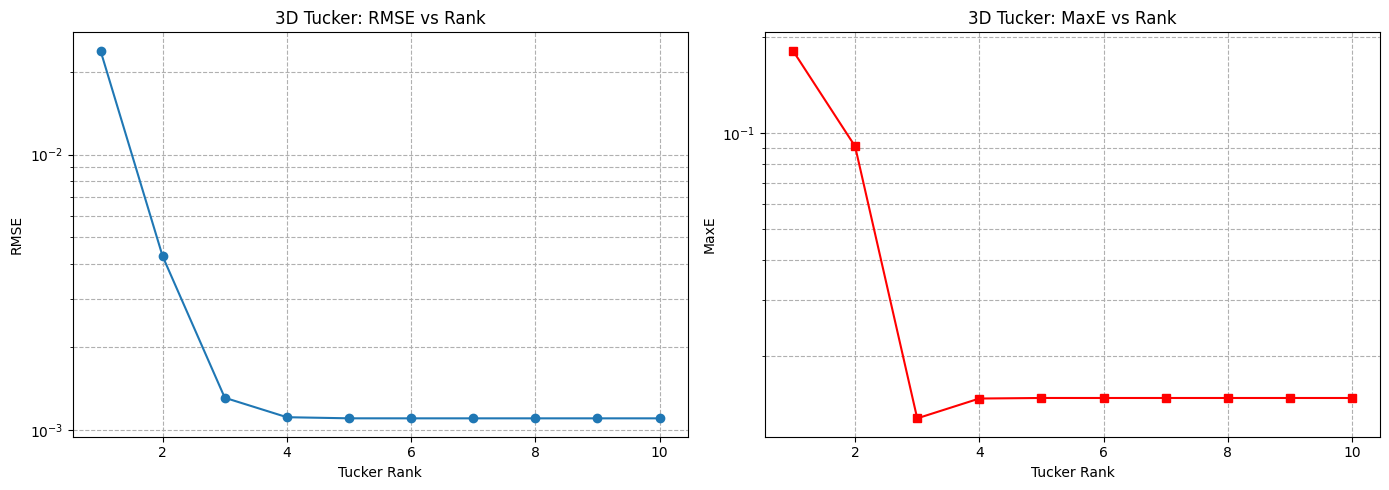

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import tucker
import tensorly as tl

# Set backend
tl.set_backend('numpy')

# Define 3D function
def f(xyz, c=5):
    return 1 / (1 + c**2 * np.sum(xyz**2, axis=1))

# Generate Chebyshev polynomials
def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Generate coefficient tensor
def generate_coeff_tensor(N, c):
    k = np.arange(N+1)
    nodes = np.cos((2*k + 1) * np.pi / (2*(N+1)))
    X, Y, Z = np.meshgrid(nodes, nodes, nodes, indexing="ij")
    coords = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
    F = f(coords, c).reshape((N+1, N+1, N+1))

    Tx = chebyshev_polys(nodes, N)
    A = np.kron(Tx.T, np.kron(Tx.T, Tx.T))
    F_flat = F.ravel()
    c_flat, *_ = np.linalg.lstsq(A, F_flat, rcond=None)
    C = c_flat.reshape((N+1, N+1, N+1))
    return C, nodes

# Evaluate function from Tucker-decomposed tensor
def evaluate_tucker_interp(core, factors, N, resolution=50):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    zz = np.linspace(-1, 1, resolution)
    Tx = chebyshev_polys(xx, N)
    Ty = chebyshev_polys(yy, N)
    Tz = chebyshev_polys(zz, N)

    A = Tx.T @ factors[0]
    B = Ty.T @ factors[1]
    C = Tz.T @ factors[2]

    F_recon = np.zeros((resolution, resolution, resolution))
    for i in range(core.shape[0]):
        for j in range(core.shape[1]):
            for k in range(core.shape[2]):
                F_recon += core[i, j, k] * np.einsum("i,j,k->ijk", A[:, i], B[:, j], C[:, k])
    return F_recon

# Compute exact ground truth
def compute_exact_function_grid(f, c, resolution=50):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    zz = np.linspace(-1, 1, resolution)
    X, Y, Z = np.meshgrid(xx, yy, zz, indexing="ij")
    coords = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
    return f(coords, c).reshape((resolution, resolution, resolution))

# Configs
N = 20
c = 5
resolution = 50
ranks = range(1, 11)

C, nodes = generate_coeff_tensor(N, c)
F_true = compute_exact_function_grid(f, c, resolution)

rmse_errors = []
maxe_errors = []

# Tucker decomposition and evaluation
for rank in ranks:
    core, factors = tucker(C, rank=[rank]*3)
    F_tucker = evaluate_tucker_interp(core, factors, N, resolution)

    diff = F_true - F_tucker
    rmse = np.sqrt(np.mean(diff**2))
    maxe = np.max(np.abs(diff))

    rmse_errors.append(rmse)
    maxe_errors.append(maxe)
    print(f"Rank {rank}, RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(ranks, rmse_errors, marker='o')
axs[0].set_yscale("log")
axs[0].set_title("3D Tucker: RMSE vs Rank")
axs[0].set_xlabel("Tucker Rank")
axs[0].set_ylabel("RMSE")
axs[0].grid(True, which='both', linestyle='--')

axs[1].plot(ranks, maxe_errors, marker='s', color='red')
axs[1].set_yscale("log")
axs[1].set_title("3D Tucker: MaxE vs Rank")
axs[1].set_xlabel("Tucker Rank")
axs[1].set_ylabel("MaxE")
axs[1].grid(True, which='both', linestyle='--')

plt.tight_layout()
plt.show()


TT Decomposition → RMSE: 1.45e-03, MaxE: 8.05e-02


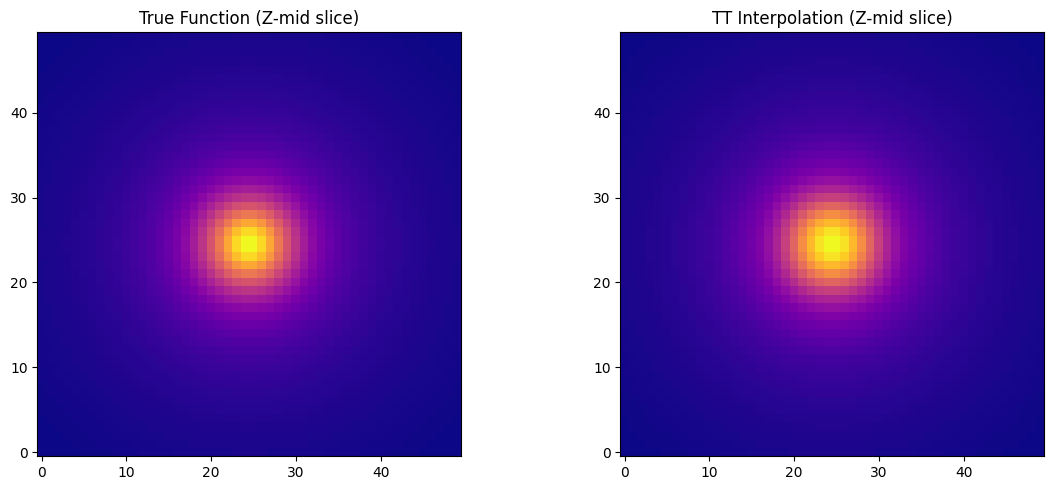

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorly.decomposition import TensorTrain
from tensorly.tt_tensor import tt_to_tensor
import tensorly as tl

# Set backend
tl.set_backend('numpy')

# Define 3D function
def f(xyz, c=5):
    return 1 / (1 + c**2 * np.sum(xyz**2, axis=1))

# Generate Chebyshev polynomials
def chebyshev_polys(x, deg):
    T = np.zeros((deg+1, len(x)))
    T[0] = 1
    if deg > 0:
        T[1] = x
    for k in range(2, deg+1):
        T[k] = 2 * x * T[k-1] - T[k-2]
    return T

# Generate coefficient tensor (N+1 should be TT-factorable)
def generate_coeff_tensor(N, c):
    k = np.arange(N+1)
    nodes = np.cos((2*k + 1) * np.pi / (2*(N+1)))
    X, Y, Z = np.meshgrid(nodes, nodes, nodes, indexing="ij")
    coords = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
    F = f(coords, c).reshape((N+1, N+1, N+1))

    Tx = chebyshev_polys(nodes, N)
    A = np.kron(Tx.T, np.kron(Tx.T, Tx.T))
    F_flat = F.ravel()
    c_flat, *_ = np.linalg.lstsq(A, F_flat, rcond=None)
    C = c_flat.reshape((N+1, N+1, N+1))
    return C, nodes

# Evaluate interpolated function using Chebyshev coefficients
def evaluate_interp(C, x_nodes, N, resolution=50):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    zz = np.linspace(-1, 1, resolution)
    Tx = chebyshev_polys(xx, N)
    Ty = chebyshev_polys(yy, N)
    Tz = chebyshev_polys(zz, N)
    F = np.zeros((resolution, resolution, resolution))
    for i in range(N+1):
        for j in range(N+1):
            for k in range(N+1):
                F += C[i, j, k] * np.einsum("i,j,k->ijk", Tx[i], Ty[j], Tz[k])
    return F

# Exact ground truth
def compute_exact_function_grid(f, c, resolution=50):
    xx = np.linspace(-1, 1, resolution)
    yy = np.linspace(-1, 1, resolution)
    zz = np.linspace(-1, 1, resolution)
    X, Y, Z = np.meshgrid(xx, yy, zz, indexing="ij")
    coords = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
    return f(coords, c).reshape((resolution, resolution, resolution))

# Configs
N = 19  # N+1 = 64, which is 2^6 and easily factorizable
c = 5
resolution = 50

# Generate Chebyshev coefficient tensor
C, x_nodes = generate_coeff_tensor(N, c)

C_tensorized = C.reshape((10,8,10,10))

# Decompose using Tensor Train
tt_model = TensorTrain(rank='same', verbose=False)
tt_cores = tt_model.fit_transform(C_tensorized)

# Reconstruct from TT cores
C_reconstructed_tensor = tt_to_tensor(tt_cores)
C_reconstructed = C_reconstructed_tensor.reshape((N+1, N+1, N+1))

# Evaluate interpolated function using reconstructed coefficients
F_tt = evaluate_interp(C_reconstructed, x_nodes, N, resolution)

# Compute ground truth
F_true = compute_exact_function_grid(f, c, resolution)

# Compute errors
diff = F_true - F_tt
rmse = np.sqrt(np.mean(diff**2))
maxe = np.max(np.abs(diff))

print(f"TT Decomposition → RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# Optional: show mid-slice comparison
mid = resolution // 2
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(F_true[mid], origin='lower', cmap='plasma')
axs[0].set_title('True Function (Z-mid slice)')
axs[1].imshow(F_tt[mid], origin='lower', cmap='plasma')
axs[1].set_title('TT Interpolation (Z-mid slice)')
plt.tight_layout()
plt.show()


In [11]:
# import numpy as np
# import matplotlib.pyplot as plt
# from tensorly.decomposition import TensorRing
# from tensorly.tt_tensor import tt_to_tensor
# import tensorly as tl

# # Set backend
# tl.set_backend('numpy')

# # Define 3D function
# def f(xyz, c=5):
#     return 1 / (1 + c**2 * np.sum(xyz**2, axis=1))

# # Generate Chebyshev polynomials
# def chebyshev_polys(x, deg):
#     T = np.zeros((deg+1, len(x)))
#     T[0] = 1
#     if deg > 0:
#         T[1] = x
#     for k in range(2, deg+1):
#         T[k] = 2 * x * T[k-1] - T[k-2]
#     return T

# # Generate coefficient tensor (N+1 should be TT-factorable)
# def generate_coeff_tensor(N, c):
#     k = np.arange(N+1)
#     nodes = np.cos((2*k + 1) * np.pi / (2*(N+1)))
#     X, Y, Z = np.meshgrid(nodes, nodes, nodes, indexing="ij")
#     coords = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
#     F = f(coords, c).reshape((N+1, N+1, N+1))

#     Tx = chebyshev_polys(nodes, N)
#     A = np.kron(Tx.T, np.kron(Tx.T, Tx.T))
#     F_flat = F.ravel()
#     c_flat, *_ = np.linalg.lstsq(A, F_flat, rcond=None)
#     C = c_flat.reshape((N+1, N+1, N+1))
#     return C, nodes

# # Evaluate interpolated function using Chebyshev coefficients
# def evaluate_interp(C, x_nodes, N, resolution=50):
#     xx = np.linspace(-1, 1, resolution)
#     yy = np.linspace(-1, 1, resolution)
#     zz = np.linspace(-1, 1, resolution)
#     Tx = chebyshev_polys(xx, N)
#     Ty = chebyshev_polys(yy, N)
#     Tz = chebyshev_polys(zz, N)
#     F = np.zeros((resolution, resolution, resolution))
#     for i in range(N+1):
#         for j in range(N+1):
#             for k in range(N+1):
#                 F += C[i, j, k] * np.einsum("i,j,k->ijk", Tx[i], Ty[j], Tz[k])
#     return F

# # Exact ground truth
# def compute_exact_function_grid(f, c, resolution=50):
#     xx = np.linspace(-1, 1, resolution)
#     yy = np.linspace(-1, 1, resolution)
#     zz = np.linspace(-1, 1, resolution)
#     X, Y, Z = np.meshgrid(xx, yy, zz, indexing="ij")
#     coords = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=1)
#     return f(coords, c).reshape((resolution, resolution, resolution))

# # Configs
# N = 19  # N+1 = 64, which is 2^6 and easily factorizable
# c = 5
# resolution = 50

# # Generate Chebyshev coefficient tensor
# C, x_nodes = generate_coeff_tensor(N, c)

# C_tensorized = C.reshape((10,8,10,10))

# # Decompose using Tensor Train
# tt_model = TensorRing(rank=8, verbose=False)
# tt_cores = tt_model.fit_transform(C_tensorized)

# # Reconstruct from TT cores
# C_reconstructed_tensor = tt_to_tensor(tt_cores)
# C_reconstructed = C_reconstructed_tensor.reshape((N+1, N+1, N+1))

# # Evaluate interpolated function using reconstructed coefficients
# F_tt = evaluate_interp(C_reconstructed, x_nodes, N, resolution)

# # Compute ground truth
# F_true = compute_exact_function_grid(f, c, resolution)

# # Compute errors
# diff = F_true - F_tt
# rmse = np.sqrt(np.mean(diff**2))
# maxe = np.max(np.abs(diff))

# print(f"TT Decomposition → RMSE: {rmse:.2e}, MaxE: {maxe:.2e}")

# # Optional: show mid-slice comparison
# mid = resolution // 2
# fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# axs[0].imshow(F_true[mid], origin='lower', cmap='plasma')
# axs[0].set_title('True Function (Z-mid slice)')
# axs[1].imshow(F_tt[mid], origin='lower', cmap='plasma')
# axs[1].set_title('TT Interpolation (Z-mid slice)')
# plt.tight_layout()
# plt.show()
